In [ ]:
!pip install pm4py

In [146]:
import os
import pandas as pd
import pm4py  # version 2.7.4
from pprint import pprint  # pretty printing
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation import algorithm as evaluation
from pm4py.objects.conversion.log import converter as stream_converter
from pm4py.objects.log.importer.xes import importer as xes_import
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

In [177]:
# Carregar o CSV
df = pd.read_csv("caseid_day/processed/event_log.csv")


# Verificar as primeiras linhas
display(df.head(5))

# Renomear colunas para os nomes esperados pelo pm4py
df = df.rename(columns={
    "case_id": "case:concept:name",
    "event_type": "concept:name",
    "timestamp": "time:timestamp",
    "value": "glucose_value"  # atributo adicional (opcional)
})

# Converter colunas principais para string
df["case:concept:name"] = df["case:concept:name"].astype(str)
df["concept:name"] = df["concept:name"].astype(str)

# Converter timestamp para datetime
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# Ordenar por caso e timestamp (obrigatório!)
df = df.sort_values(["case:concept:name", "time:timestamp"])

# Converter para EventLog
event_log = pm4py.convert_to_event_log(df)

# (Opcional) Também manter como DataFrame para análise
log_df = df.copy()

print("✅ Event log carregado com sucesso!")
print(f"Total de traces (casos): {len(event_log)}")
print(f"Total de eventos: {len(log_df)}")

,case_id,event_type,timestamp,value
0,2023-10-22,Meal,2023-10-22 10:00:00,NaN
1,2023-10-22,PPGR_peak,2023-10-22 10:44:00,9.400000
2,2023-10-22,Meal,2023-10-22 12:00:00,NaN
3,2023-10-22,PPGR_peak,2023-10-22 13:29:00,15.600000
4,2023-10-22,PPGR_recovery,2023-10-22 14:34:00,9.158333


✅ Event log carregado com sucesso!
Total de traces (casos): 85
Total de eventos: 1288


In [178]:
# Estrutura de um trace e de um evento
print("Atributos de um trace (case):")
print(list(event_log[0].attributes.keys()))

print("\nCampos de um evento:")
print(list(event_log[0][0].keys()))

# Atividades únicas
print("\nAtividades únicas:")
print(log_df["concept:name"].unique().tolist())

# Atividades iniciais e finais
print("\nAtividades iniciais:")
print(pm4py.get_start_activities(event_log))

print("\nAtividades finais:")
print(pm4py.get_end_activities(event_log))

Atributos de um trace (case):
['concept:name']

Campos de um evento:
['concept:name', 'time:timestamp', 'glucose_value']

Atividades únicas:
['Meal', 'PPGR_peak', 'PPGR_recovery', 'BolusInsulin']

Atividades iniciais:
{'Meal': 83, 'BolusInsulin': 2}

Atividades finais:
{'PPGR_peak': 30, 'PPGR_recovery': 40, 'BolusInsulin': 15}


In [179]:
# Heuristics Miner (recomendado para logs reais)
h_net, h_im, h_fm = heuristics_miner.apply(event_log)

# Inductive Miner
tree = inductive_miner.apply(event_log)
i_net, i_im, i_fm = pm4py.convert_to_petri_net(tree)

# Alpha Miner (menos robusto, só para comparação)
a_net, a_im, a_fm = alpha_miner.apply(event_log)

print("✅ Modelos gerados com sucesso!")

✅ Modelos gerados com sucesso!


In [180]:
# Acho que só é preciso correr uma vez, a partir daí está -- (é para a visualização dos gráficos)

#!apt-get update >/dev/null 2>&1
#!apt-get install -y graphviz >/dev/null 2>&1



In [181]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer


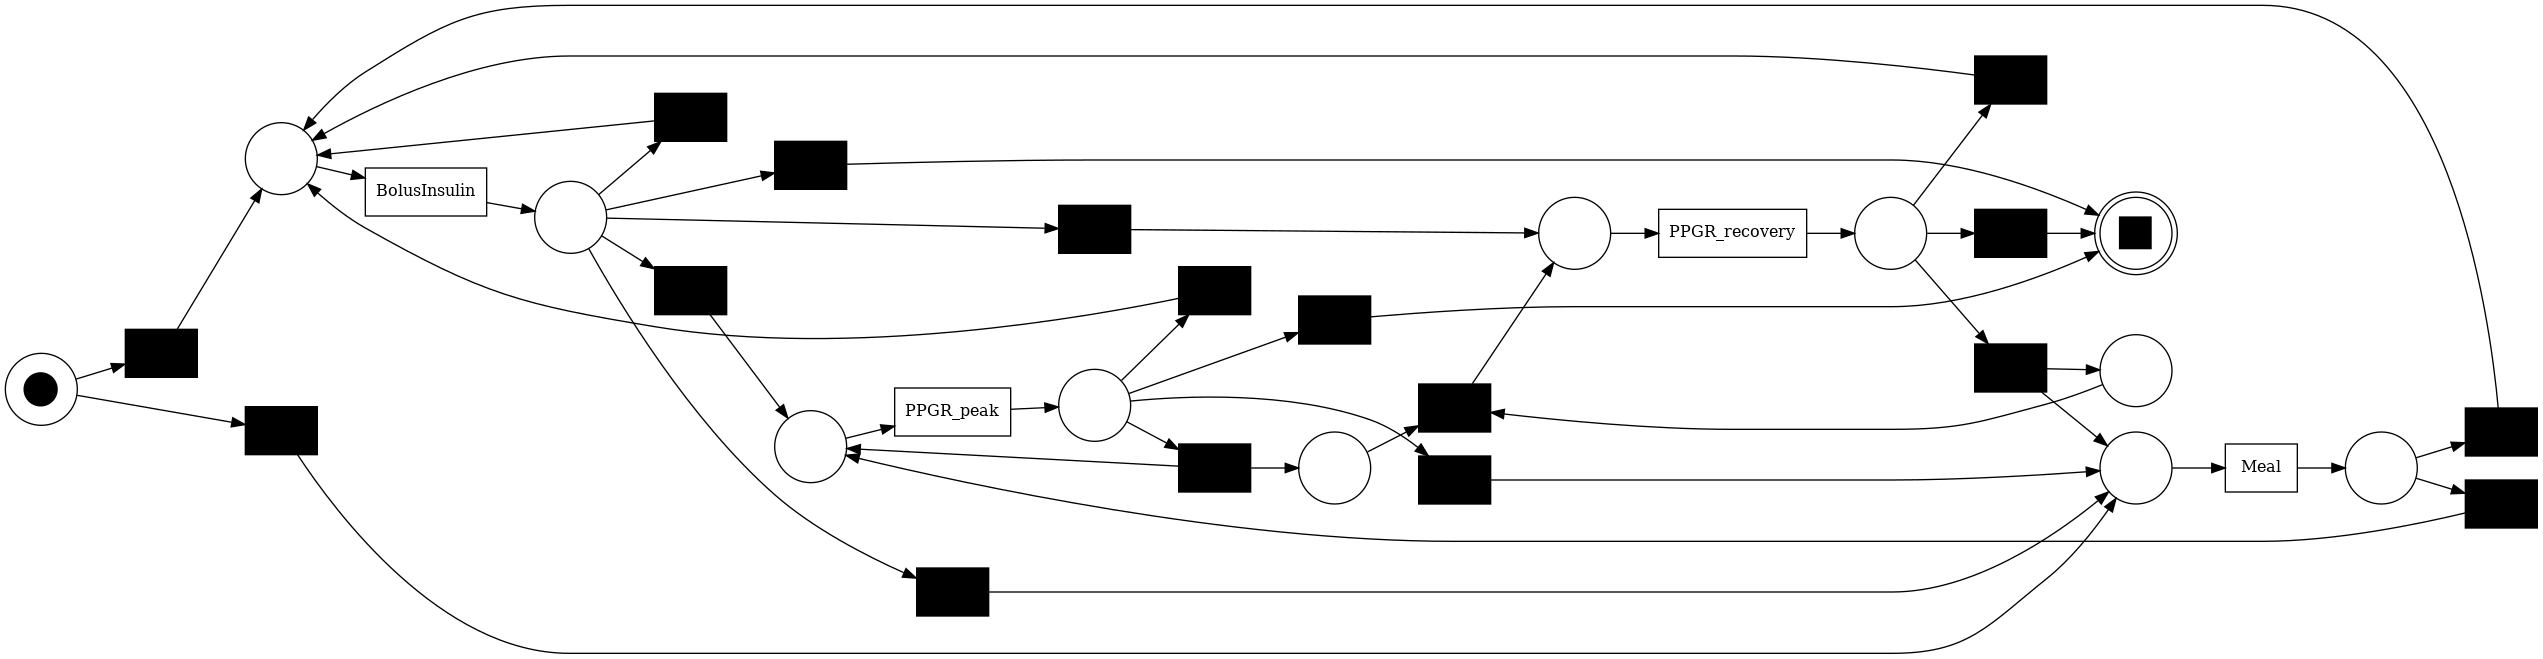

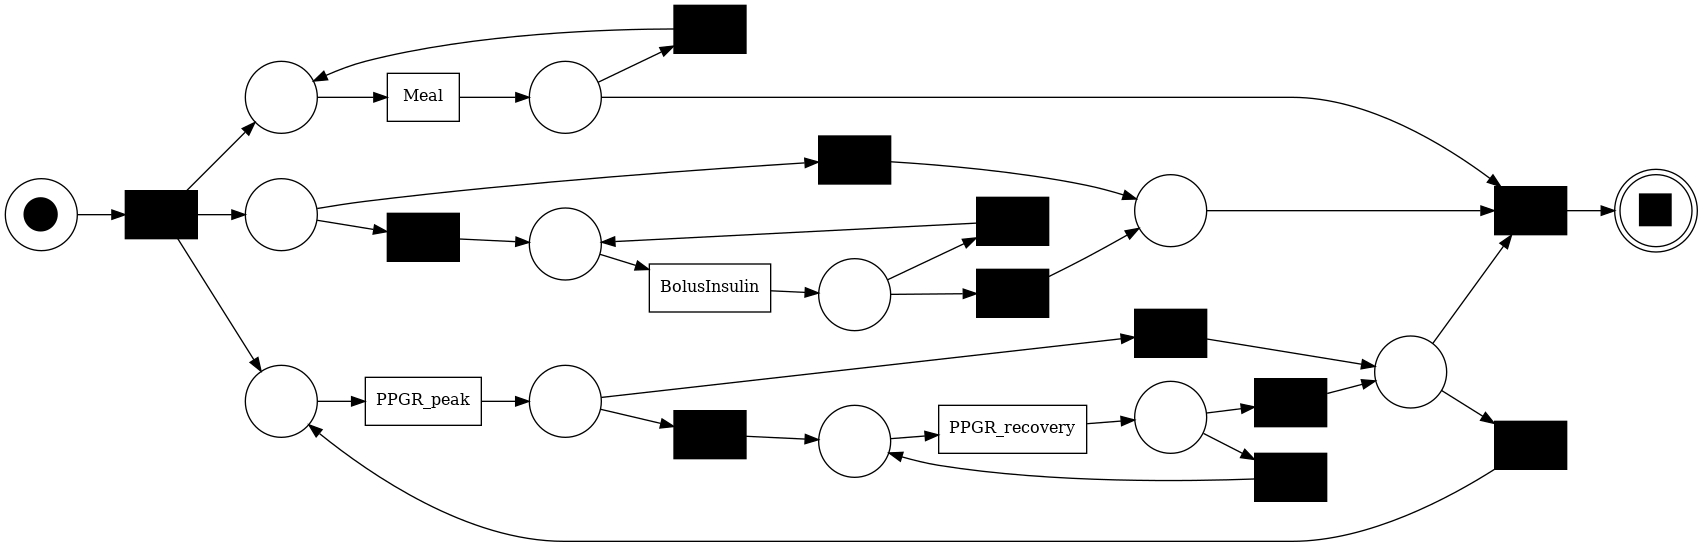

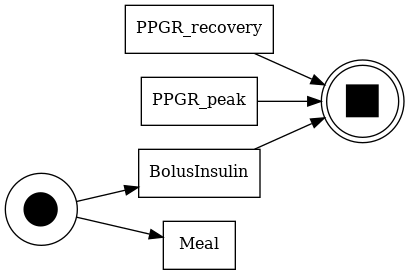

Visualizações criadas e guardadas!


In [182]:

# ===============================
# VISUALIZAÇÃO DOS MODELOS
# ===============================

# --- Heuristics Miner ---
h_gviz = pn_visualizer.apply(h_net, h_im, h_fm)
pn_visualizer.view(h_gviz)
pn_visualizer.save(h_gviz, "data_grafsalterados/graphs/heuristics_miner_petrinet.png")

# --- Inductive Miner ---
i_gviz = pn_visualizer.apply(i_net, i_im, i_fm)
pn_visualizer.view(i_gviz)
pn_visualizer.save(i_gviz, "data_grafsalterados/graphs/inductive_miner_petrinet.png")

# --- Alpha Miner ---
a_gviz = pn_visualizer.apply(a_net, a_im, a_fm)
pn_visualizer.view(a_gviz)
pn_visualizer.save(a_gviz, "data_grafsalterados/graphs/alpha_miner_petrinet.png")

print("Visualizações criadas e guardadas!")


In [183]:
## --- Recall and Comprehensibility ---


def compute_recall(eval_result):
    precision = eval_result["precision"]
    fscore = eval_result["fscore"]

    # evitar divisões por zero
    if precision == 0 or (2 * precision - fscore) == 0:
        return 0.0

    recall = (fscore * precision) / (2 * precision - fscore)
    return recall

def compute_comprehensibility(net):
    num_places = len(net.places)
    num_transitions = len(net.transitions)

    total_elements = num_places + num_transitions

    if total_elements == 0:
        return 0.0

    # quanto menor a estrutura, maior o score
    return 1 / total_elements

In [184]:
# Avaliar Heuristics Miner
eval_h = evaluation.apply(event_log, h_net, h_im, h_fm)
recall_h = compute_recall(eval_h)
eval_h["recall"] = recall_h
compreh_h = compute_comprehensibility(h_net)
eval_h["comprehensibility"] = compreh_h

# Avaliar Inductive Miner
eval_i = evaluation.apply(event_log, i_net, i_im, i_fm)
recall_i = compute_recall(eval_i)
eval_i["recall"] = recall_i
compreh_i = compute_comprehensibility(i_net)
eval_i["comprehensibility"] = compreh_i

# Avaliar Alpha Miner
eval_a = evaluation.apply(event_log, a_net, a_im, a_fm)
recall_a = compute_recall(eval_a)
eval_a["recall"] = recall_a
compreh_a = compute_comprehensibility(a_net)
eval_a["comprehensibility"] = compreh_a

print("Avaliação - Heuristics Miner:")
pprint(eval_h)

print("\nAvaliação - Inductive Miner:")
pprint(eval_i)

print("\nAvaliação - Alpha Miner:")
pprint(eval_a)

replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

Avaliação - Heuristics Miner:
{'comprehensibility': 0.030303030303030304,
 'fitness': {'average_trace_fitness': 0.9522080483230136,
             'log_fitness': 0.9532634385344743,
             'perc_fit_traces': 21.176470588235293,
             'percentage_of_fitting_traces': 21.176470588235293},
 'fscore': 0.7013625919547247,
 'generalization': 0.8562287214295308,
 'metricsAverageWeight': 0.7358012049981136,
 'precision': 0.5547652916073968,
 'recall': 0.9532634385344742,
 'simplicity': 0.5789473684210527}

Avaliação - Inductive Miner:
{'comprehensibility': 0.034482758620689655,
 'fitness': {'average_trace_fitness': 1.0,
             'log_fitness': 1.0,
             'perc_fit_traces': 100.0,
             'percentage_of_fitting_traces': 100.0},
 'fscore': 0.6013426653335239,
 'generalization': 0.8976936501905138,
 'metricsAverageWeight': 0.7505137663247982,
 'precision': 0.42994281045751637,
 'recall': 1.0000000000000004,
 'simplicity': 0.6744186046511628}

Avaliação - Alpha Miner:
{'c

In [185]:
# Verificar quais traces se encaixam perfeitamente no modelo (Heuristics)
print("\n Replaying log with TBR - Heuristics Miner:")
replayed_h = token_replay.apply(event_log, h_net, h_im, h_fm)

# Contar traces que NÃO se encaixam
not_fit_h = sum(1 for trace in replayed_h if not trace['trace_is_fit'])
total_h = len(replayed_h)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_h} de {total_h}")
print(f"Taxa de conformidade: {(1 - not_fit_h/total_h)*100:.1f}%")

print("\n Replaying log with TBR - Inductive Miner:")
replayed_i = token_replay.apply(event_log, i_net, i_im, i_fm)

# Contar traces que NÃO se encaixam
not_fit_i = sum(1 for trace in replayed_i if not trace['trace_is_fit'])
total_i = len(replayed_i)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_i} de {total_i}")
print(f"Taxa de conformidade: {(1 - not_fit_i/total_i)*100:.1f}%")

print("\n Replaying log with TBR - Alpha Miner:")
replayed_a = token_replay.apply(event_log, a_net, a_im, a_fm)

# Contar traces que NÃO se encaixam
not_fit_a = sum(1 for trace in replayed_a if not trace['trace_is_fit'])
total_a = len(replayed_a)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_a} de {total_a}")
print(f"Taxa de conformidade: {(1 - not_fit_a/total_a)*100:.1f}%")


 Replaying log with TBR - Heuristics Miner:


replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

Traces que NÃO se ajustam ao modelo: 67 de 85
Taxa de conformidade: 21.2%

 Replaying log with TBR - Inductive Miner:


replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

Traces que NÃO se ajustam ao modelo: 0 de 85
Taxa de conformidade: 100.0%

 Replaying log with TBR - Alpha Miner:


replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

Traces que NÃO se ajustam ao modelo: 85 de 85
Taxa de conformidade: 0.0%


In [186]:
# Tempo médio entre "Meal" e "PPGR_peak"
meal_to_peak = log_df[log_df["concept:name"] == "PPGR_peak"].copy()
meal_to_peak = meal_to_peak.merge(
    log_df[log_df["concept:name"] == "Meal"][["case:concept:name", "time:timestamp"]].rename(
        columns={"time:timestamp": "meal_time"}
    ),
    on="case:concept:name",
    how="inner"
)

meal_to_peak["time_to_peak"] = (
    meal_to_peak["time:timestamp"] - meal_to_peak["meal_time"]
).dt.total_seconds() / 60  # em minutos

print(f"\nTempo médio para atingir o pico: {meal_to_peak['time_to_peak'].mean():.1f} minutos")

# Valor médio do pico
peak_values = log_df[log_df["concept:name"] == "PPGR_peak"]["glucose_value"]
print(f"Valor médio do pico: {peak_values.mean():.2f} mmol/L")


Tempo médio para atingir o pico: 68.1 minutos
Valor médio do pico: 10.65 mmol/L
